In [27]:
import os 
from typing import List, Optional, TypedDict
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document


C:\Users\HP\AppData\Local\Temp\ipykernel_15936\1864373799.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS
c:\Users\HP\OneDrive\Desktop\Rag\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

google_api_key = os.getenv("GOOGLE_API_KEY")

print("API key loaded:", google_api_key is not None)
print("API key prefix:", google_api_key[:6] if google_api_key else "None")

API key loaded: True
API key prefix: AQ.Ab8


In [29]:
from google import genai

client = genai.Client(api_key=google_api_key)
result = client.models.embed_content(
    model="gemini-embedding-2",
    contents="What is RAG?"
)

test_embedding = result.embeddings[0].values

print("Embedding dimensions:", len(test_embedding))
print(test_embedding[:5])


Embedding dimensions: 3072
[0.0051715183, 0.017824814, 0.0054058293, 0.00999092, 0.005611693]


In [33]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_openai import OpenAIEmbeddings



# Gemini LLM
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0,
    google_api_key=google_api_key
)

embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-2",
    google_api_key=google_api_key
)

In [36]:
test_embedding = embeddings.embed_query("What is RAG?")

print("Embedding dimensions:", len(test_embedding))
print(test_embedding[:5])

Embedding dimensions: 3072
[0.0051715183, 0.017824814, 0.0054058293, 0.00999092, 0.005611693]


In [34]:
class AgentState(TypedDict):
    question: str
    documents: list[Document]
    answer: Optional[str]
    needs_retrieval: bool

In [35]:
sample_texts = [
    "RAG (Retrieval-Augmented Generation) combines document retrieval with an LLM to generate answers using relevant external information.",
    
    "LLM (Large Language Model) is an AI model trained on large amounts of text to understand and generate human-like responses.",
    
    "Agentic AI refers to AI systems that can reason, make decisions, use tools, and execute multiple steps to achieve a goal.",
    
    "Vector Database stores numerical vector embeddings and enables fast similarity searches based on semantic meaning.",
    
    "Embeddings are numerical representations of text that capture semantic meaning and allow similar concepts to be compared mathematically.",
    
    "Semantic Search retrieves information based on the meaning of a query rather than exact keyword matching.",
    
    "LangChain is a framework for building LLM applications using prompts, retrievers, tools, agents, and vector databases.",
    
    "LangGraph is a framework for building stateful, multi-step, and controllable AI agent workflows.",
    
    "RAG Pipeline typically follows Documents → Chunking → Embeddings → Vector Database → Retrieval → LLM → Answer.",
    
    "RAG Agents combine retrieval with agentic reasoning so an AI agent can decide when and how to retrieve information.",
    
    "Fine-Tuning adapts an LLM's behavior or capabilities by training it further on a specialized dataset."
]


documents = [
    Document(page_content=text)
    for text in sample_texts
]

vectorstore = FAISS.from_documents(
    documents,
    embedding=embeddings
)

retriever = vectorstore.as_retriever(k=3)

In [45]:
def decide_retrieval(state: AgentState) -> AgentState:
    query = state["question"]
    retrieval_keywords=["what","how","when","describe","why","explain","tell me"]
    need_retrieval = any(keyword in query.lower() for keyword in retrieval_keywords)
    return {**state, "needs_retrieval": need_retrieval}

In [46]:
def retrieve_documents(state: AgentState) -> AgentState:
    query = state["question"]
    documents= retriever.invoke(query)

    return {**state, "documents": documents}

In [ ]:
def generate_answer(state: AgentState) -> AgentState:
    question = state["question"]
    documents = state.get("documents", [])
    
    context = "\n".join(doc.page_content for doc in documents)

    if documents:
        context = "\n".join(doc.page_content for doc in documents)
        prompt = f"Answer the following question based on the provided context:\n\nContext:\n{context}\n\nQuestion: {question}\n\nAnswer:"
    
    else:
        prompt = f"Answer the following question:\n\nQuestion: {question}\n\nAnswer:"

    response = llm.invoke(prompt)
    answer = response.content
    
    return {**state, "answer": answer}

In [48]:
def should_retrieve(state: AgentState) -> str:
    if state["needs_retrieval"]:
        return "retrieve"
    else:
        return "generate"

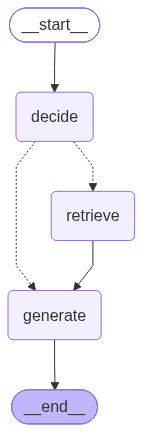

In [54]:
workflow = StateGraph(AgentState)
workflow.add_node("decide", decide_retrieval)
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("generate", generate_answer)


workflow.set_entry_point("decide")
workflow.add_conditional_edges(
    "decide",
    should_retrieve,
    {
        "retrieve": "retrieve",
        "generate": "generate"
    }
    )

workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

app=workflow.compile()
app

In [55]:
def ask_question(question: str) -> str:
    initial_state: AgentState = {
        "question": question,
        "documents": [],
        "answer": "",
        "needs_retrieval": False
    }
    
    result = app.invoke(initial_state)
    return result

In [56]:
question = "What is RAG?"
result = ask_question(question)
result

c:\Users\HP\OneDrive\Desktop\Rag\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'question': 'What is RAG?',
 'documents': [Document(id='53694195-e081-4d71-93c8-ea0a45865d68', metadata={}, page_content='RAG (Retrieval-Augmented Generation) combines document retrieval with an LLM to generate answers using relevant external information.'),
  Document(id='577cc970-cf90-4bb7-b1ed-9f74a75e77f9', metadata={}, page_content='RAG Pipeline typically follows Documents → Chunking → Embeddings → Vector Database → Retrieval → LLM → Answer.'),
  Document(id='2b62224a-50d5-4a35-b78d-5c3e9b14a0df', metadata={}, page_content='RAG Agents combine retrieval with agentic reasoning so an AI agent can decide when and how to retrieve information.'),
  Document(id='6797d3da-adb3-4116-bfe8-e3923e4f718c', metadata={}, page_content='LangChain is a framework for building LLM applications using prompts, retrievers, tools, agents, and vector databases.')],
 'answer': [{'type': 'text',
   'text': 'Based on the provided context, RAG (Retrieval-Augmented Generation) combines document retrieval with

In [57]:
question2 = "Explain the RAG pipeline."
result2 = ask_question(question2)

print("Question 2:", question2)
print(f"Retrieved documents: {len(result2['documents'])}")
print(f"Answer: {result2['answer']}")
print("\n" + "=" * 50 + "\n")

c:\Users\HP\OneDrive\Desktop\Rag\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Question 2: Explain the RAG pipeline.
Retrieved documents: 4
Answer: [{'type': 'text', 'text': 'Based on the provided context, RAG (Retrieval-Augmented Generation) combines document retrieval with a Large Language Model (LLM) to generate answers using relevant external information. \n\nThe RAG pipeline typically follows these sequential steps:\n1. **Documents**\n2. **Chunking**\n3. **Embeddings**\n4. **Vector Database**\n5. **Retrieval**\n6. **LLM**\n7. **Answer**', 'extras': {'signature': 'EsEMCr4MAWkUfROZGPZ5OC0LU6NcB5/SGqEf/qixcasiT2k85U0uM/BVUoP2dxRZhrGfHXfGva/+3gMoe5WQtKNpABFYU6fyX5f1Gf7jb1TmoTOqPWv9IdE57mnr+41lQtpqOt+GPVrpDE6JBPH4kCOW0F0Gg9EFsmrA8VEkFi3RlSXYW6oNacmjS3Y1FXoXEyPhezCN16OlU8wUyiJ0RUhEEMfcpL6iDBkSybFH71Qagcl4ozHZJvKvjuBg6WIj/LmAFVLF9BDsIaDDlNRTIFSpM7HmOe1LiA3aUSGcVP/P5zJJFMUc4RMuCMufXNtstxXGkl/3LVkNE1xiHqRWPU5iflFyg9jH8fnzCbjZykC/uAeqeT6yPZ52B8xM8gTXptnDvqC2AboUxUjDjHcPUnOxQQ4cHcJzZ1e4fIXR0uqROOO1qsLItOPEMBv0ivMoi9tbXZUPHXKT6JSpZkTJPzEwmZhOTbKT8FjxnjLG2TNzFOoBIeMAB/p3